# 01 - Exploratory Data Analysis (EDA)

## CDC Diabetes Health Indicators Dataset

This notebook performs comprehensive exploratory data analysis on the CDC BRFSS 2015 dataset to understand the data structure, distributions, relationships, and identify potential issues before modelling.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Loading and Initial Inspection

In [2]:
# Load dataset
df = pd.read_csv('../data/CDC Diabetes Dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Number of samples: {df.shape[0]:,}')
print(f'Number of features: {df.shape[1]}')
print()
df.head(10)

Dataset shape: (253680, 22)
Number of samples: 253,680
Number of features: 22



,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [3]:
# Data types and basic info
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Dataset Info ===')
df.info()

=== Data Types ===
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non

In [4]:
# Statistical summary
df.describe().round(2)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.0,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.3,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,0.81,0.06,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.7,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,0.39,0.23,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.0,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.0,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.0,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.0,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,2.0,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


## 2. Missing Values and Data Quality Check

In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
print(missing_df)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values ===
                      Missing Count  Missing %
Diabetes_012                      0        0.0
HighBP                            0        0.0
HighChol                          0        0.0
CholCheck                         0        0.0
BMI                               0        0.0
Smoker                            0        0.0
Stroke                            0        0.0
HeartDiseaseorAttack              0        0.0
PhysActivity                      0        0.0
Fruits                            0        0.0
Veggies                           0        0.0
HvyAlcoholConsump                 0        0.0
AnyHealthcare                     0        0.0
NoDocbcCost                       0        0.0
GenHlth                           0        0.0
MentHlth                          0        0.0
PhysHlth                          0        0.0
DiffWalk                          0        0.0
Sex                               0        0.0
Age                               0  

In [6]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates:,}')
print(f'Percentage of duplicates: {duplicates/len(df)*100:.2f}%')
print(f'\nUnique rows: {len(df) - duplicates:,}')

Number of duplicate rows: 23,899
Percentage of duplicates: 9.42%

Unique rows: 229,781


In [7]:
# Check unique values for each feature to understand data types
print('=== Unique Values per Feature ===')
for col in df.columns:
    unique_vals = df[col].nunique()
    print(f'{col:25s}: {unique_vals:6d} unique values | Range: [{df[col].min()}, {df[col].max()}]')

=== Unique Values per Feature ===
Diabetes_012             :      3 unique values | Range: [0.0, 2.0]
HighBP                   :      2 unique values | Range: [0.0, 1.0]
HighChol                 :      2 unique values | Range: [0.0, 1.0]
CholCheck                :      2 unique values | Range: [0.0, 1.0]
BMI                      :     84 unique values | Range: [12.0, 98.0]
Smoker                   :      2 unique values | Range: [0.0, 1.0]
Stroke                   :      2 unique values | Range: [0.0, 1.0]
HeartDiseaseorAttack     :      2 unique values | Range: [0.0, 1.0]
PhysActivity             :      2 unique values | Range: [0.0, 1.0]
Fruits                   :      2 unique values | Range: [0.0, 1.0]
Veggies                  :      2 unique values | Range: [0.0, 1.0]
HvyAlcoholConsump        :      2 unique values | Range: [0.0, 1.0]
AnyHealthcare            :      2 unique values | Range: [0.0, 1.0]
NoDocbcCost              :      2 unique values | Range: [0.0, 1.0]
GenHlth     

## 3. Target Variable Analysis (Class Imbalance)

=== Target Variable Distribution ===
No Diabetes     (class 0.0):  213,703 samples (84.24%)
Prediabetes     (class 1.0):    4,631 samples (1.83%)
Diabetes        (class 2.0):   35,346 samples (13.93%)


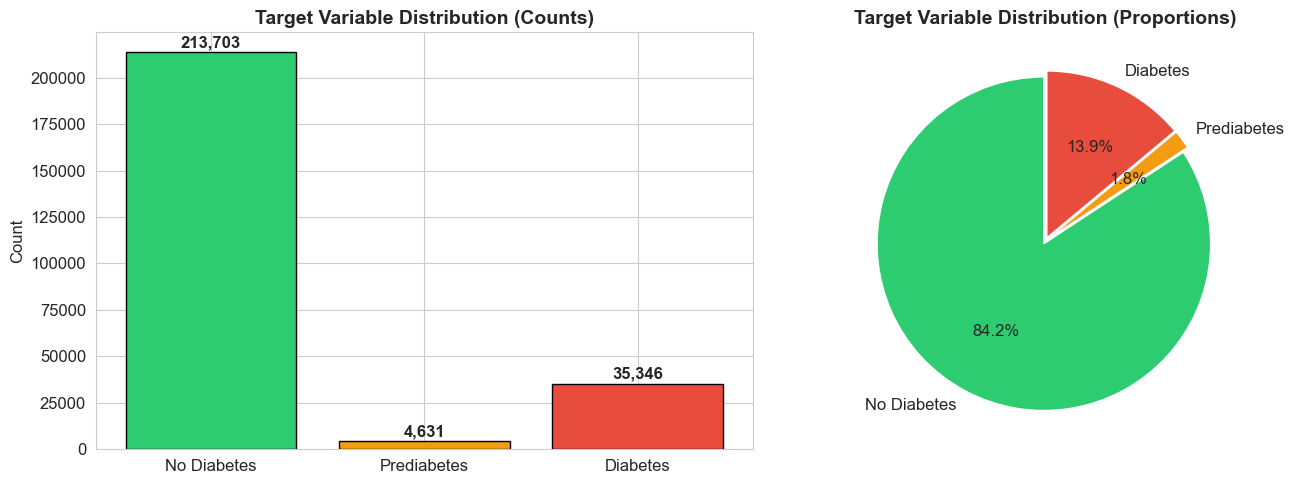


⚠️ Severe class imbalance detected!
Ratio (No Diabetes : Prediabetes : Diabetes) = 84.2% : 1.8% : 13.9%


In [8]:
# Target variable distribution
target_counts = df['Diabetes_012'].value_counts().sort_index()
target_pcts = df['Diabetes_012'].value_counts(normalize=True).sort_index() * 100

print('=== Target Variable Distribution ===')
labels = {0: 'No Diabetes', 1: 'Prediabetes', 2: 'Diabetes'}
for val in target_counts.index:
    print(f'{labels[val]:15s} (class {val}): {target_counts[val]:>8,} samples ({target_pcts[val]:.2f}%)')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar([labels[i] for i in target_counts.index], target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Target Variable Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1000,
                f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=[labels[i] for i in target_counts.index],
           autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.02, 0.02, 0.02))
axes[1].set_title('Target Variable Distribution (Proportions)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n⚠️ Severe class imbalance detected!')
print(f'Ratio (No Diabetes : Prediabetes : Diabetes) = {target_pcts[0]:.1f}% : {target_pcts[1]:.1f}% : {target_pcts[2]:.1f}%')

## 4. Feature Distributions

In [9]:
# Identify binary vs continuous vs ordinal features
binary_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
                   'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                   'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

ordinal_features = ['GenHlth', 'Age', 'Education', 'Income']

continuous_features = ['BMI', 'MentHlth', 'PhysHlth']

print(f'Binary features ({len(binary_features)}): {binary_features}')
print(f'Ordinal features ({len(ordinal_features)}): {ordinal_features}')
print(f'Continuous features ({len(continuous_features)}): {continuous_features}')

Binary features (14): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Ordinal features (4): ['GenHlth', 'Age', 'Education', 'Income']
Continuous features (3): ['BMI', 'MentHlth', 'PhysHlth']


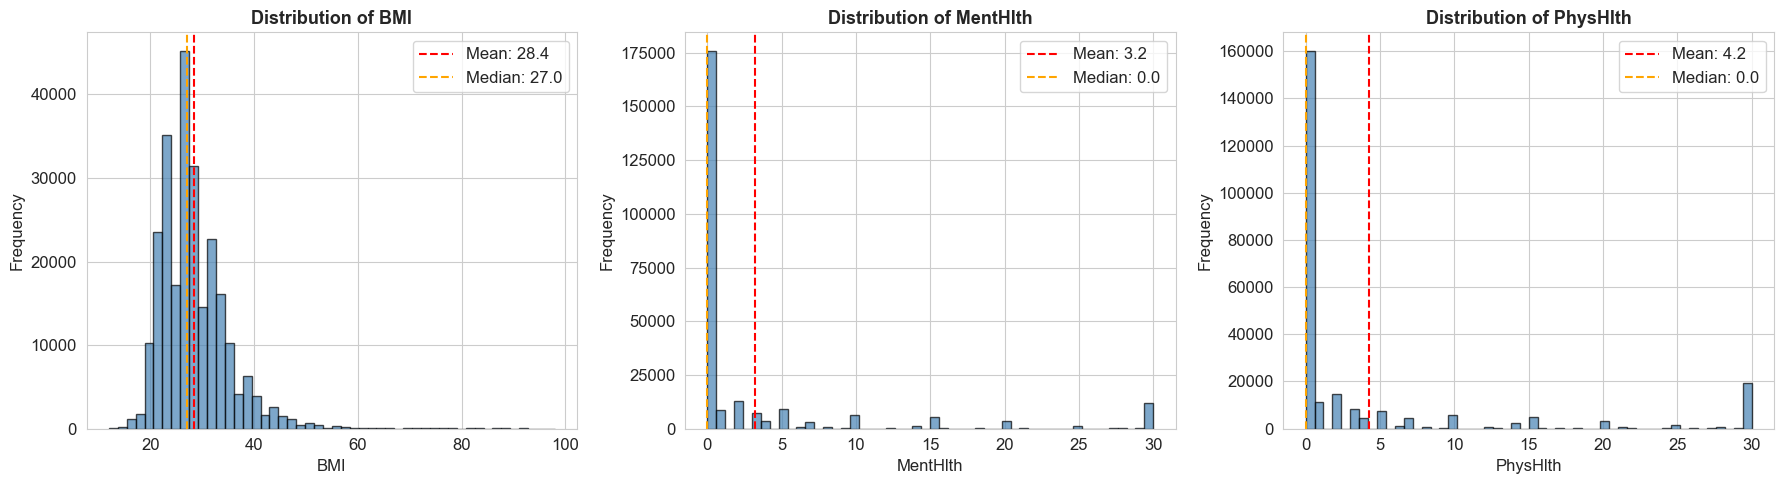

In [10]:
# Distribution of continuous features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(continuous_features):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../notebooks/figures/continuous_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

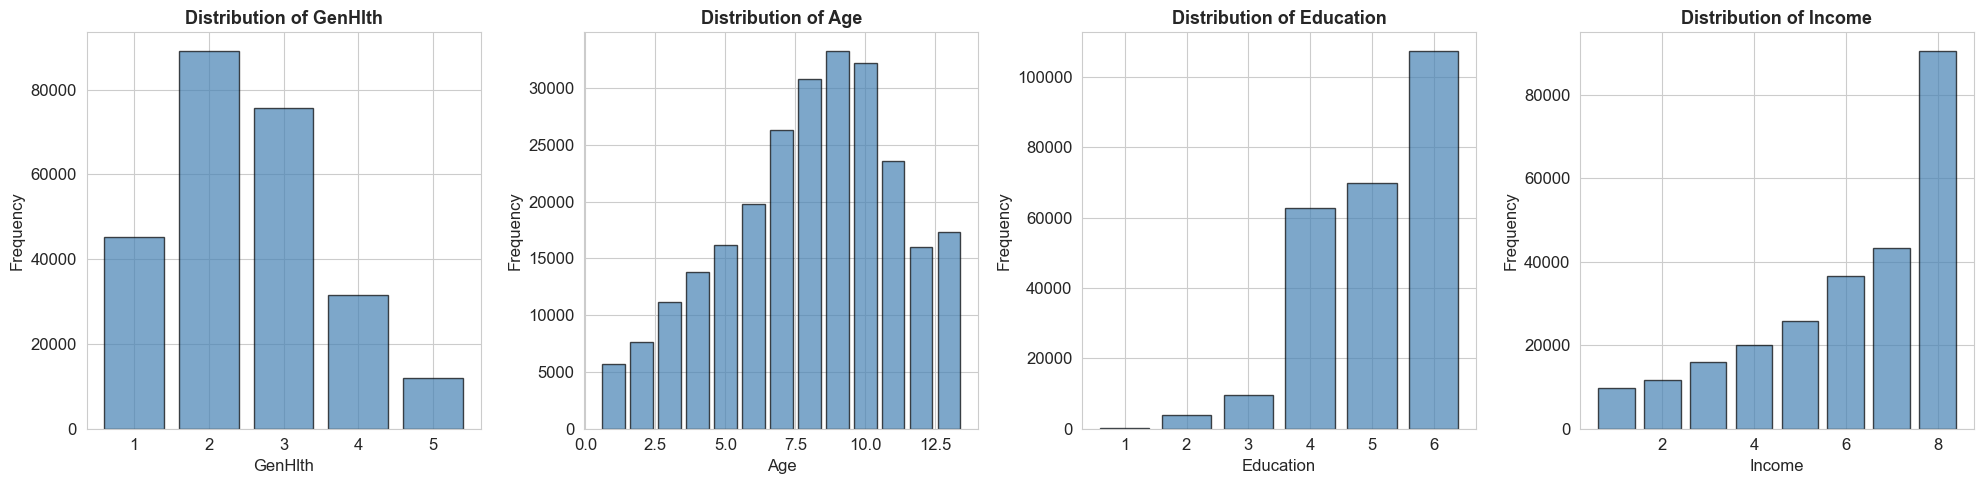

In [11]:
# Distribution of ordinal features
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(ordinal_features):
    value_counts = df[col].value_counts().sort_index()
    axes[i].bar(value_counts.index, value_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../notebooks/figures/ordinal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

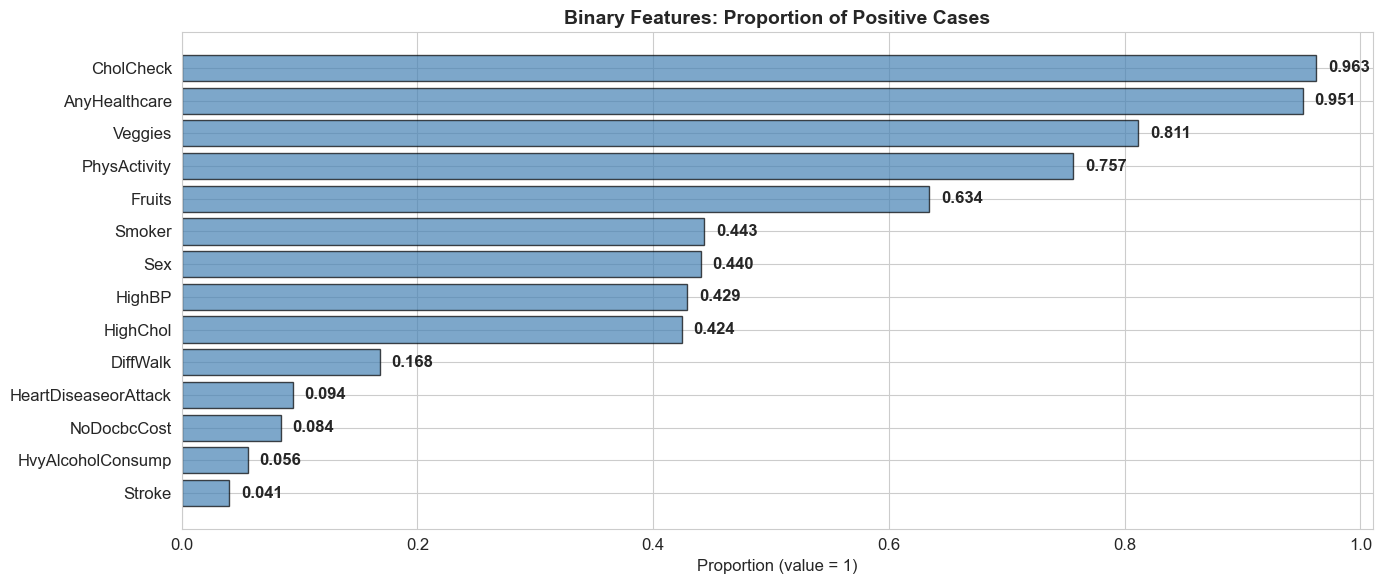

In [12]:
# Distribution of binary features - proportion of 1s
fig, ax = plt.subplots(figsize=(14, 6))

binary_means = df[binary_features].mean().sort_values(ascending=True)
bars = ax.barh(binary_means.index, binary_means.values, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Proportion (value = 1)', fontsize=12)
ax.set_title('Binary Features: Proportion of Positive Cases', fontsize=14, fontweight='bold')

for bar, val in zip(bars, binary_means.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2., f'{val:.3f}',
           va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/binary_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

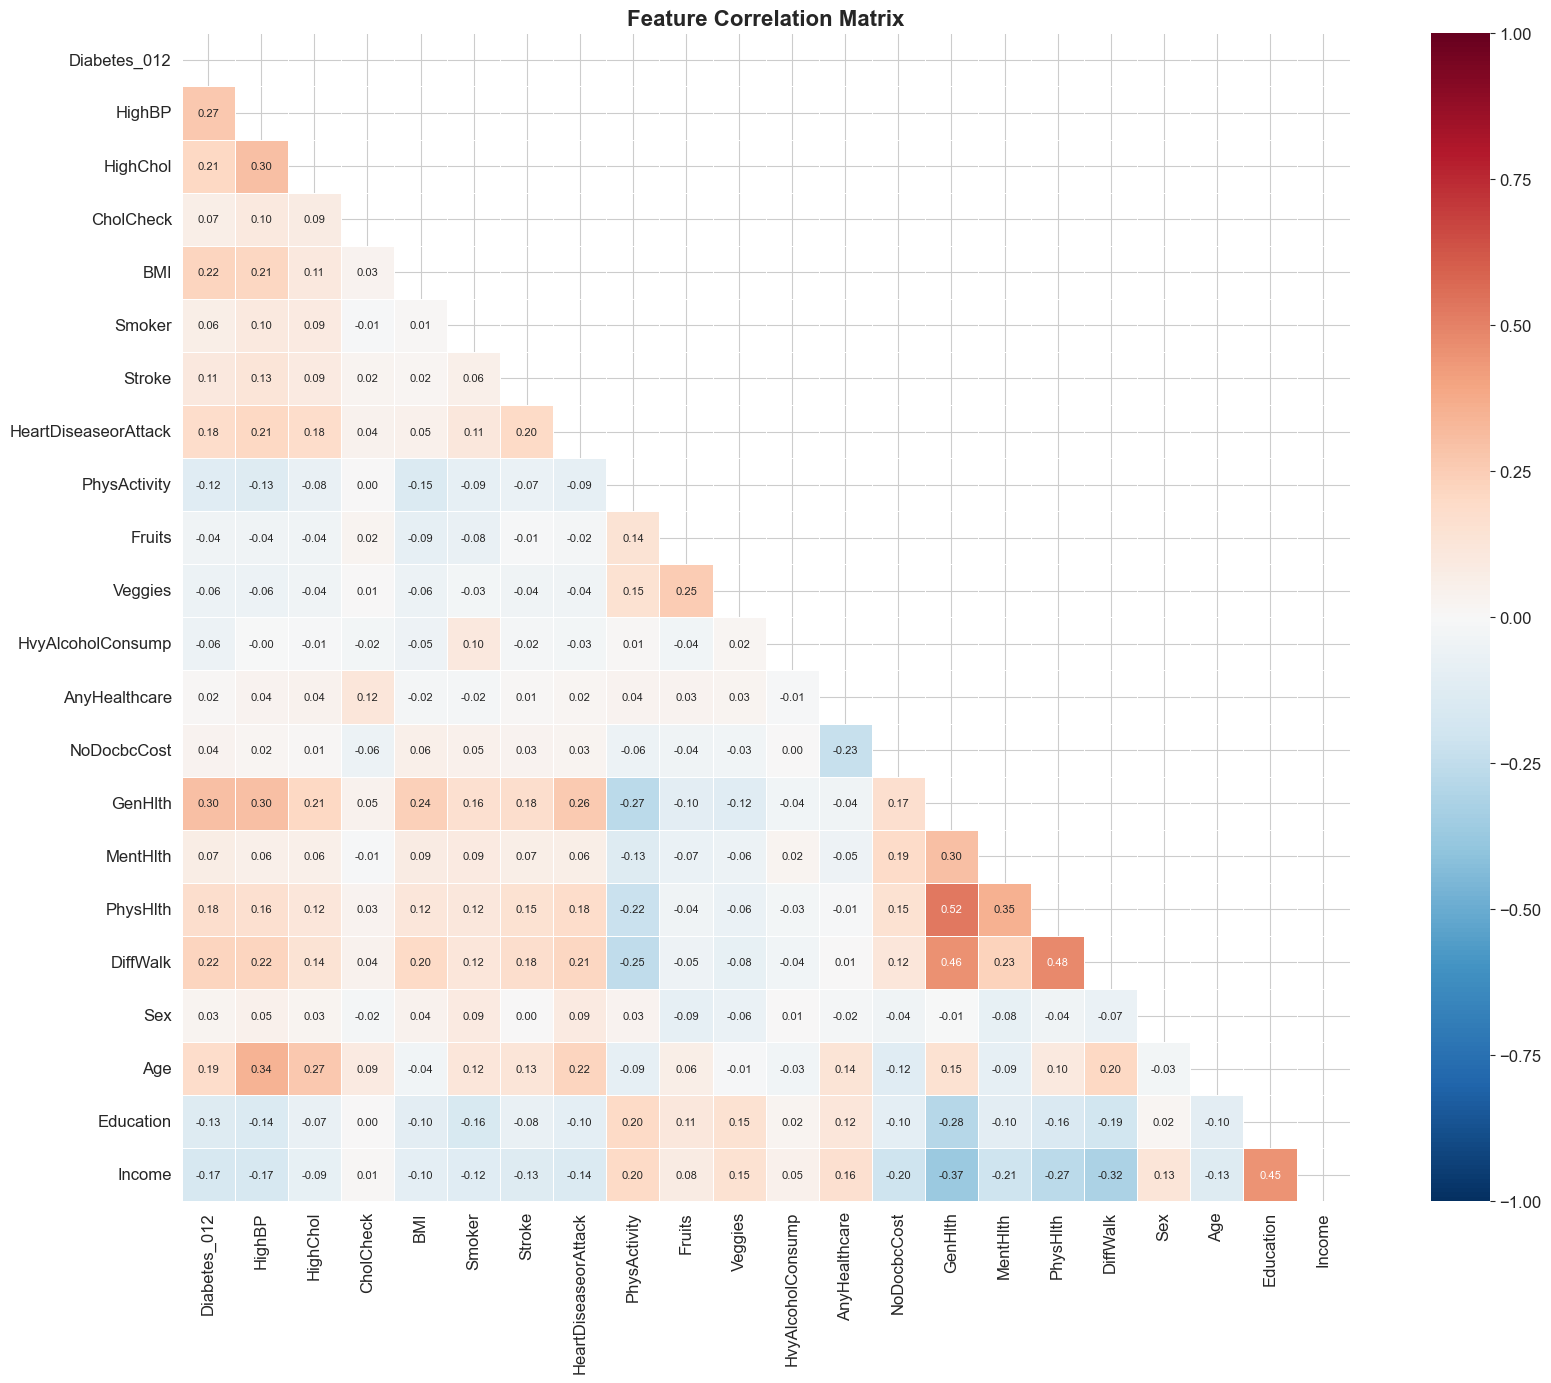


=== Correlation with Target Variable (Diabetes_012) ===
GenHlth                  : +0.3026
HighBP                   : +0.2716
BMI                      : +0.2244
DiffWalk                 : +0.2242
HighChol                 : +0.2091
Age                      : +0.1850
HeartDiseaseorAttack     : +0.1803
PhysHlth                 : +0.1763
Stroke                   : +0.1072
MentHlth                 : +0.0735
CholCheck                : +0.0675
Smoker                   : +0.0629
NoDocbcCost              : +0.0354
Sex                      : +0.0310
AnyHealthcare            : +0.0154
Fruits                   : -0.0422
HvyAlcoholConsump        : -0.0579
Veggies                  : -0.0590
PhysActivity             : -0.1219
Education                : -0.1305
Income                   : -0.1715


In [13]:
# Correlation matrix heatmap
fig, ax = plt.subplots(figsize=(18, 14))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
           center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
           ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation with target
print('\n=== Correlation with Target Variable (Diabetes_012) ===')
target_corr = corr_matrix['Diabetes_012'].drop('Diabetes_012').sort_values(ascending=False)
for feature, corr in target_corr.items():
    print(f'{feature:25s}: {corr:+.4f}')

## 6. Feature vs Target Analysis

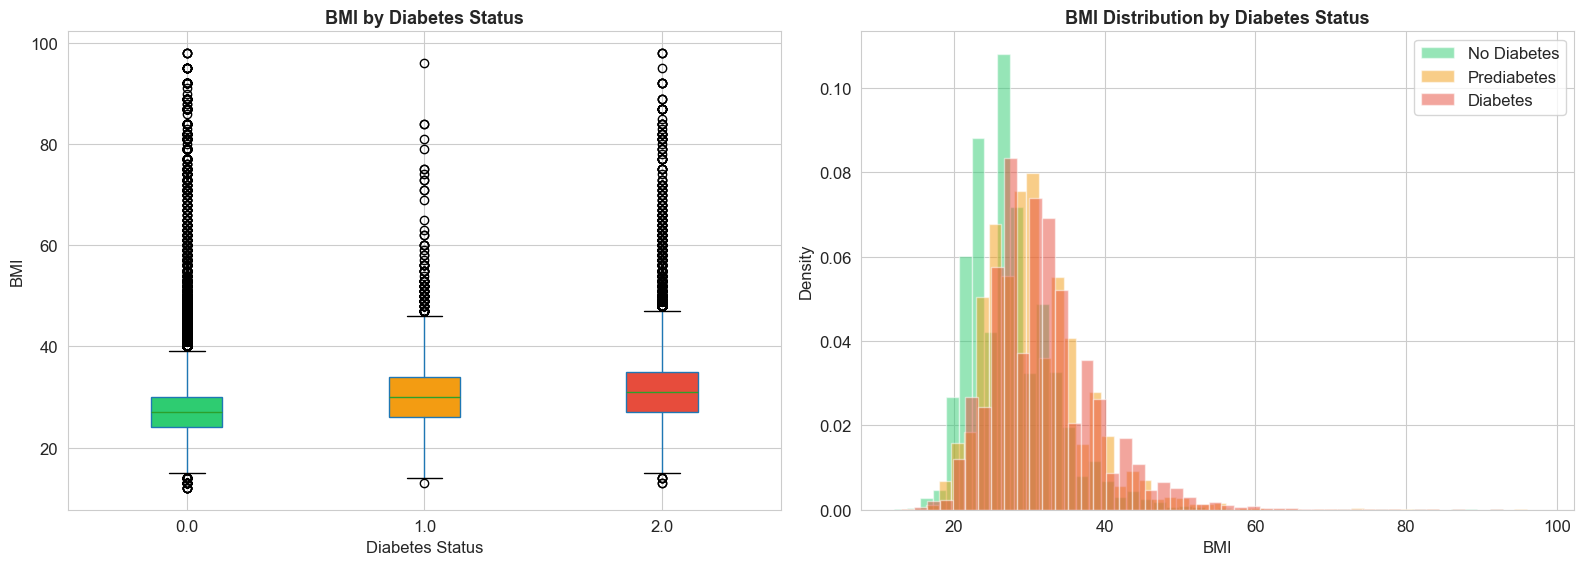

In [14]:
# BMI distribution across diabetes categories
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
colors_map = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
bp = df.boxplot(column='BMI', by='Diabetes_012', ax=axes[0], patch_artist=True,
               return_type='dict')
for patch, color in zip(bp['BMI']['boxes'], colors_map.values()):
    patch.set_facecolor(color)
axes[0].set_title('BMI by Diabetes Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diabetes Status')
axes[0].set_ylabel('BMI')
plt.suptitle('')  # Remove auto title from boxplot

# KDE plot
for cls, label in labels.items():
    subset = df[df['Diabetes_012'] == cls]['BMI']
    axes[1].hist(subset, bins=50, alpha=0.5, label=label, color=colors_map[cls], density=True)
axes[1].set_title('BMI Distribution by Diabetes Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/figures/bmi_vs_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

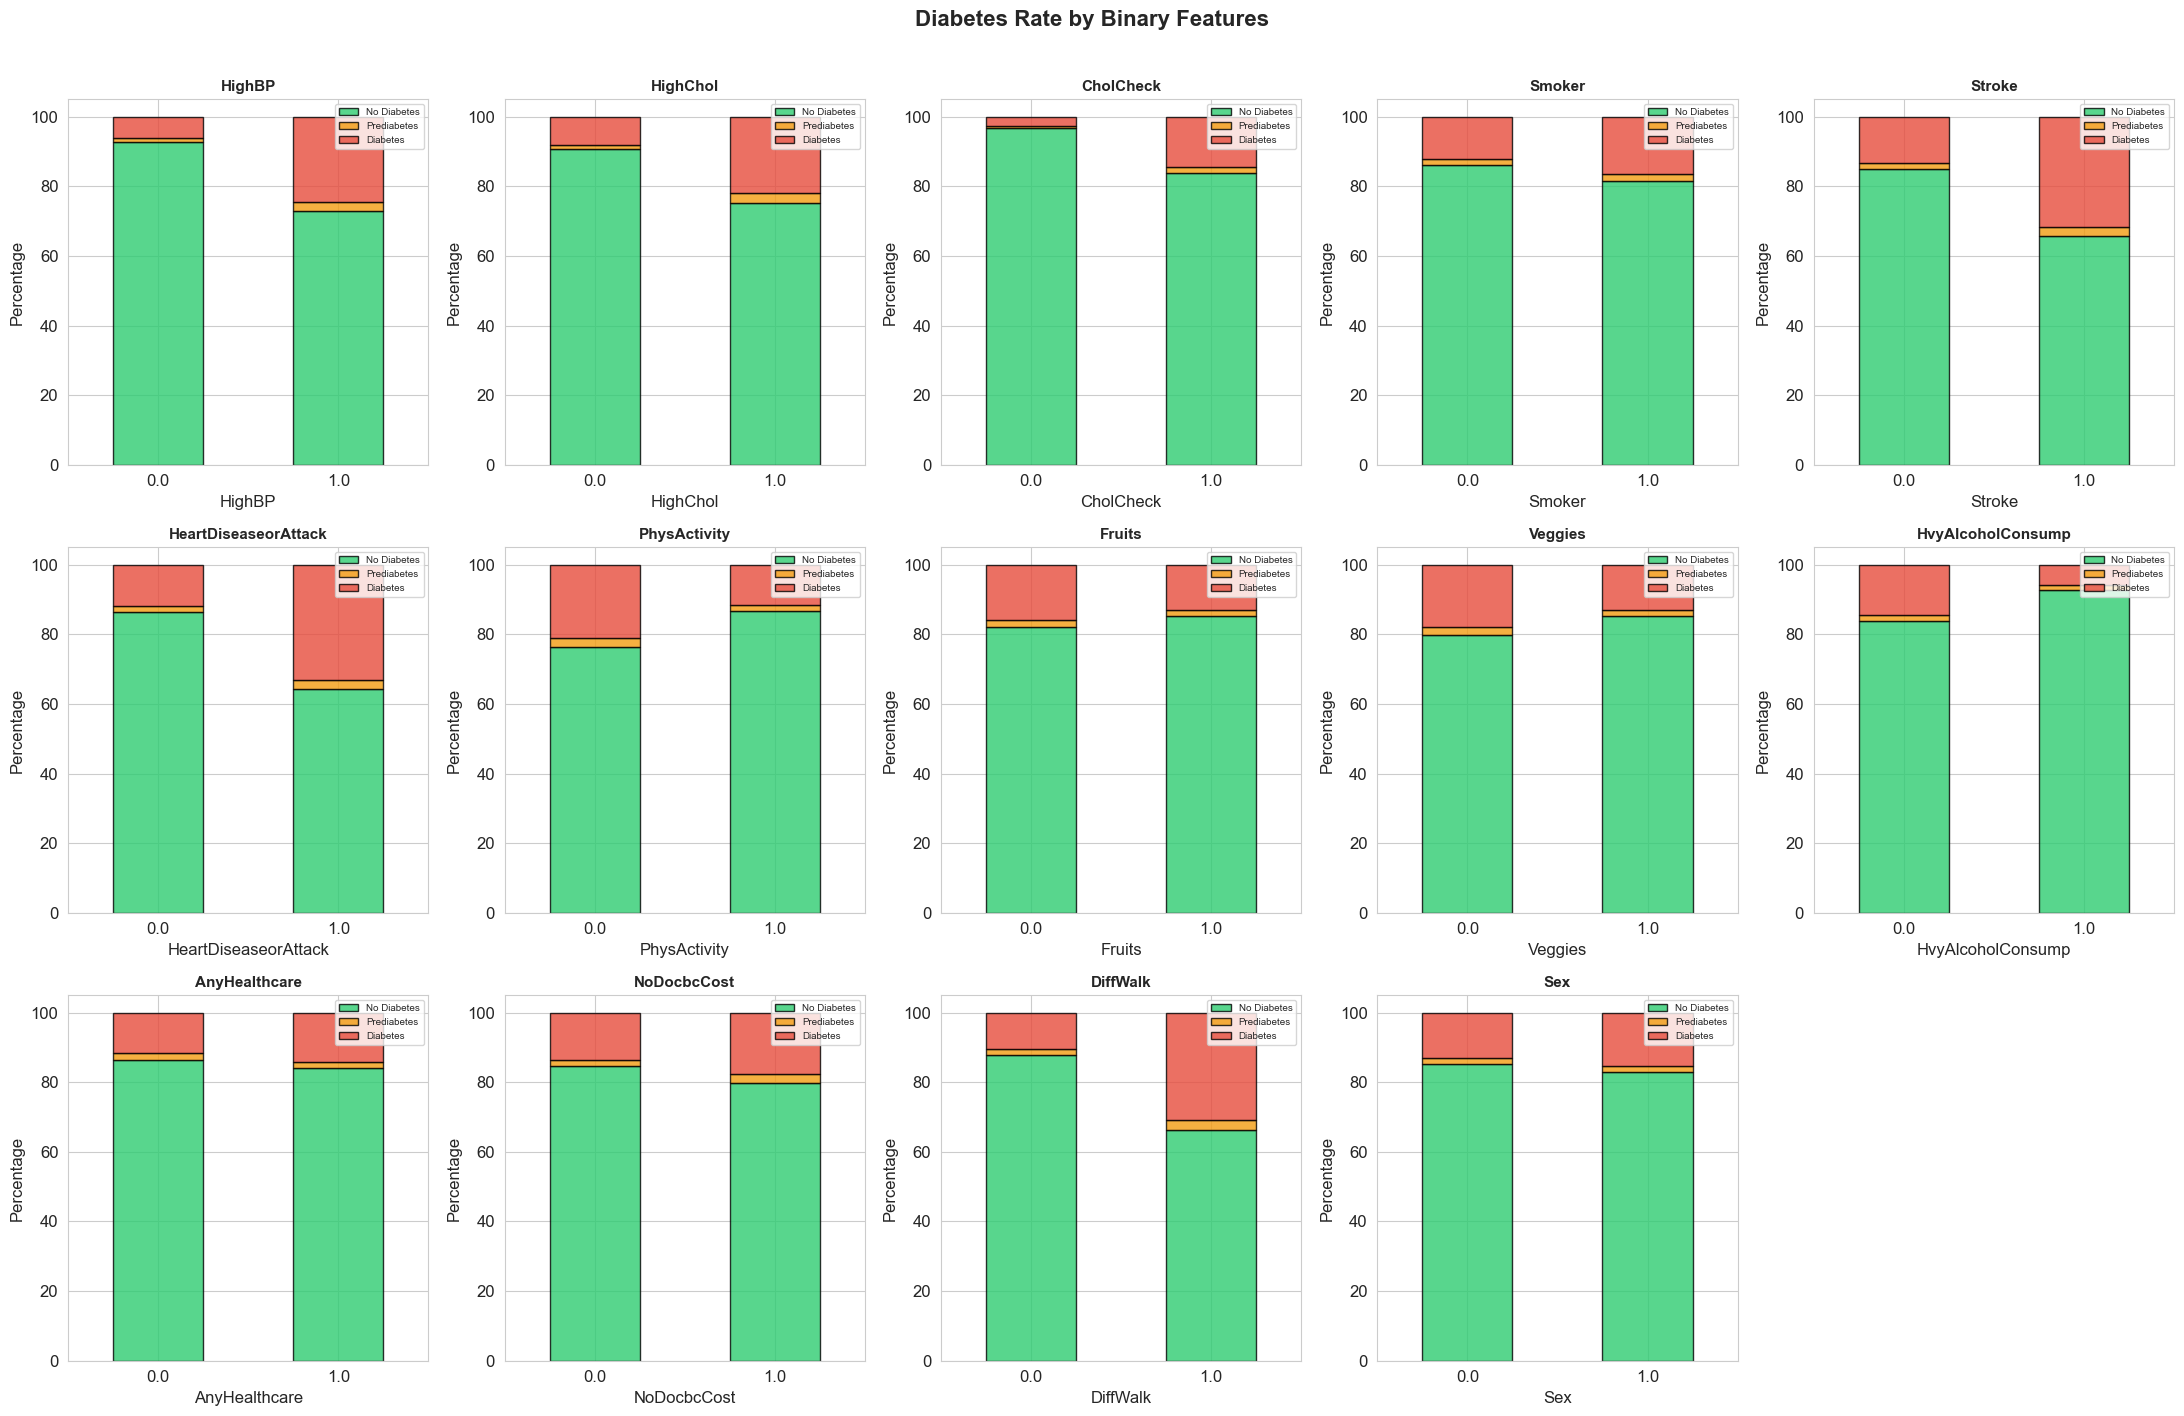

In [15]:
# Binary features: rate of diabetes for each binary feature
fig, axes = plt.subplots(3, 5, figsize=(22, 14))
axes = axes.flatten()

for i, col in enumerate(binary_features):
    ct = pd.crosstab(df[col], df['Diabetes_012'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=colors, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].legend(['No Diabetes', 'Prediabetes', 'Diabetes'], fontsize=7, loc='upper right')

# Remove extra subplot
axes[-1].set_visible(False)

plt.suptitle('Diabetes Rate by Binary Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/binary_vs_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

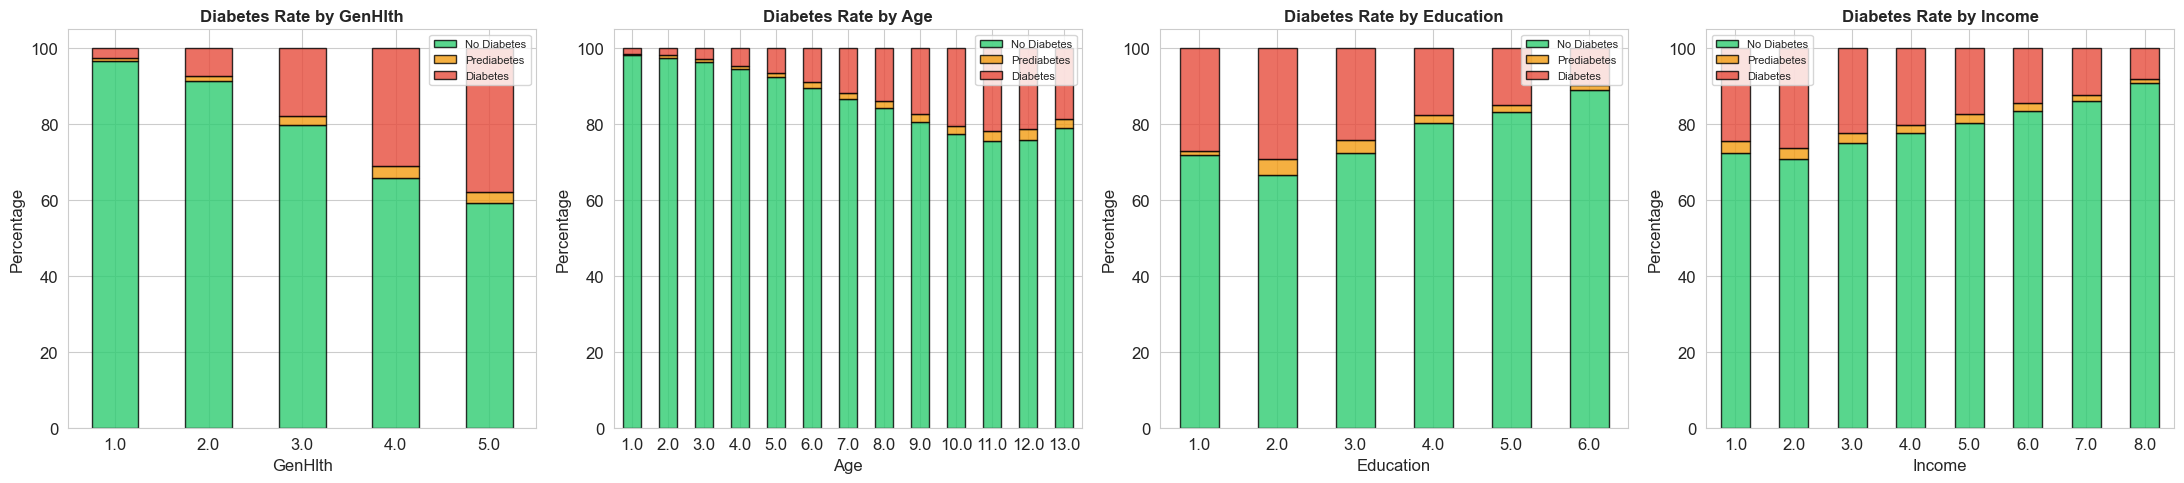

In [16]:
# Ordinal features vs target
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, col in enumerate(ordinal_features):
    ct = pd.crosstab(df[col], df['Diabetes_012'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=colors, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Diabetes Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].legend(['No Diabetes', 'Prediabetes', 'Diabetes'], fontsize=8)

plt.tight_layout()
plt.savefig('../notebooks/figures/ordinal_vs_diabetes.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Outlier Detection

=== Outlier Detection (IQR Method) ===
BMI            : Q1=24.0, Q3=31.0, IQR=7.0, Bounds=[13.5, 41.5], Outliers=9,847 (3.88%)
MentHlth       : Q1=0.0, Q3=2.0, IQR=2.0, Bounds=[-3.0, 5.0], Outliers=36,208 (14.27%)
PhysHlth       : Q1=0.0, Q3=3.0, IQR=3.0, Bounds=[-4.5, 7.5], Outliers=40,949 (16.14%)


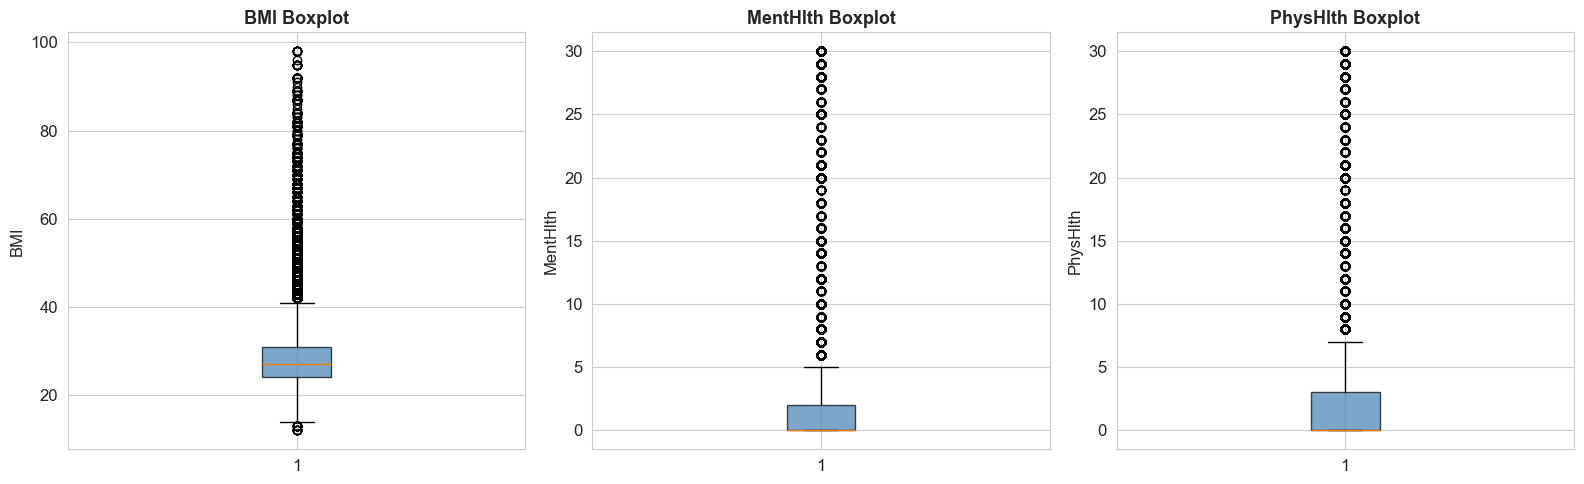

In [17]:
# Check outliers for continuous features using IQR method
print('=== Outlier Detection (IQR Method) ===')
for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col:15s}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, '
          f'Bounds=[{lower:.1f}, {upper:.1f}], Outliers={len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)')

# Boxplot of continuous features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(continuous_features):
    axes[i].boxplot(df[col], patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(f'{col} Boxplot', fontsize=13, fontweight='bold')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('../notebooks/figures/outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance - Mutual Information Analysis

Mutual information measures the dependency between each feature and the target variable, capturing non-linear relationships that correlation cannot detect.

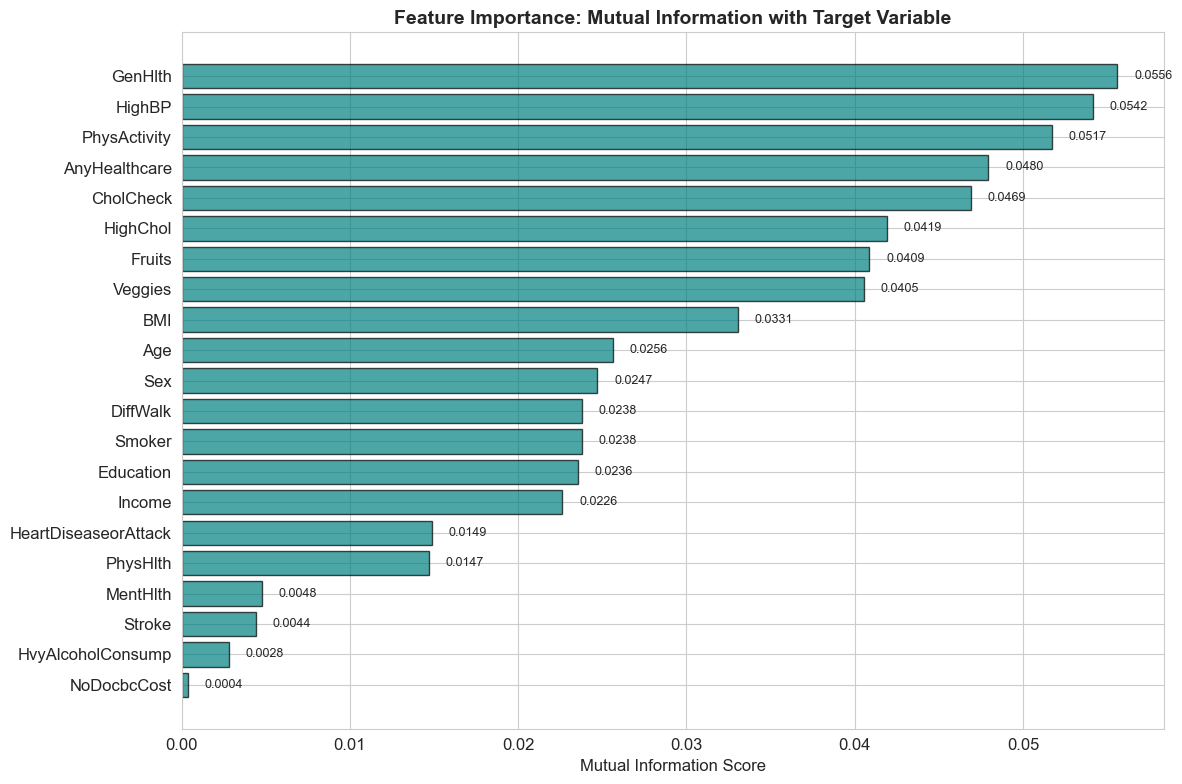


Top 10 most informative features:
  GenHlth                  : 0.0556
  HighBP                   : 0.0542
  PhysActivity             : 0.0517
  AnyHealthcare            : 0.0480
  CholCheck                : 0.0469
  HighChol                 : 0.0419
  Fruits                   : 0.0409
  Veggies                  : 0.0405
  BMI                      : 0.0331
  Age                      : 0.0256


In [18]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information between features and target
features = df.drop('Diabetes_012', axis=1)
target = df['Diabetes_012']

mi_scores = mutual_info_classif(features, target, random_state=42)
mi_df = pd.DataFrame({'Feature': features.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(mi_df['Feature'], mi_df['MI Score'], color='teal', edgecolor='black', alpha=0.7)
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_title('Feature Importance: Mutual Information with Target Variable', fontsize=14, fontweight='bold')

for bar, val in zip(bars, mi_df['MI Score']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2., f'{val:.4f}',
           va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/figures/mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 most informative features:')
for _, row in mi_df.sort_values('MI Score', ascending=False).head(10).iterrows():
    print(f"  {row['Feature']:25s}: {row['MI Score']:.4f}")

## 9. PCA Visualisation (2D Projection)

Using PCA to reduce the dataset to 2 dimensions for visualisation. This gives an initial idea of how separable the classes are.

Explained variance ratio: PC1=0.1671, PC2=0.0840
Total variance explained by 2 components: 0.2511


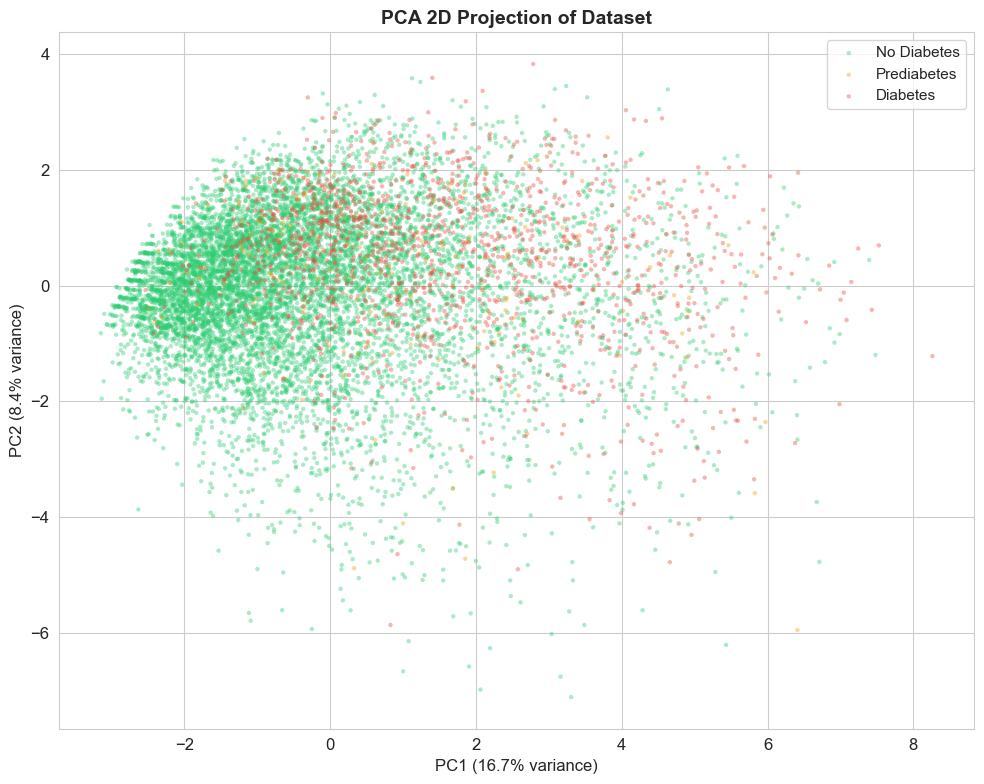

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardise features for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Apply PCA with 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.4f}, PC2={pca.explained_variance_ratio_[1]:.4f}')
print(f'Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.4f}')

# Plot PCA scatter (use sample for performance)
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), size=10000, replace=False)

fig, ax = plt.subplots(figsize=(10, 8))
for cls, label, color in zip([0, 1, 2], ['No Diabetes', 'Prediabetes', 'Diabetes'], ['#2ecc71', '#f39c12', '#e74c3c']):
    mask = target.values[sample_idx] == cls
    ax.scatter(X_pca[sample_idx][mask, 0], X_pca[sample_idx][mask, 1],
              c=color, label=label, alpha=0.4, s=10, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA 2D Projection of Dataset', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../notebooks/figures/pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. PCA - Explained Variance Analysis

Examining how many principal components are needed to capture most of the variance in the dataset.

Components for 90% variance: 17
Components for 95% variance: 19


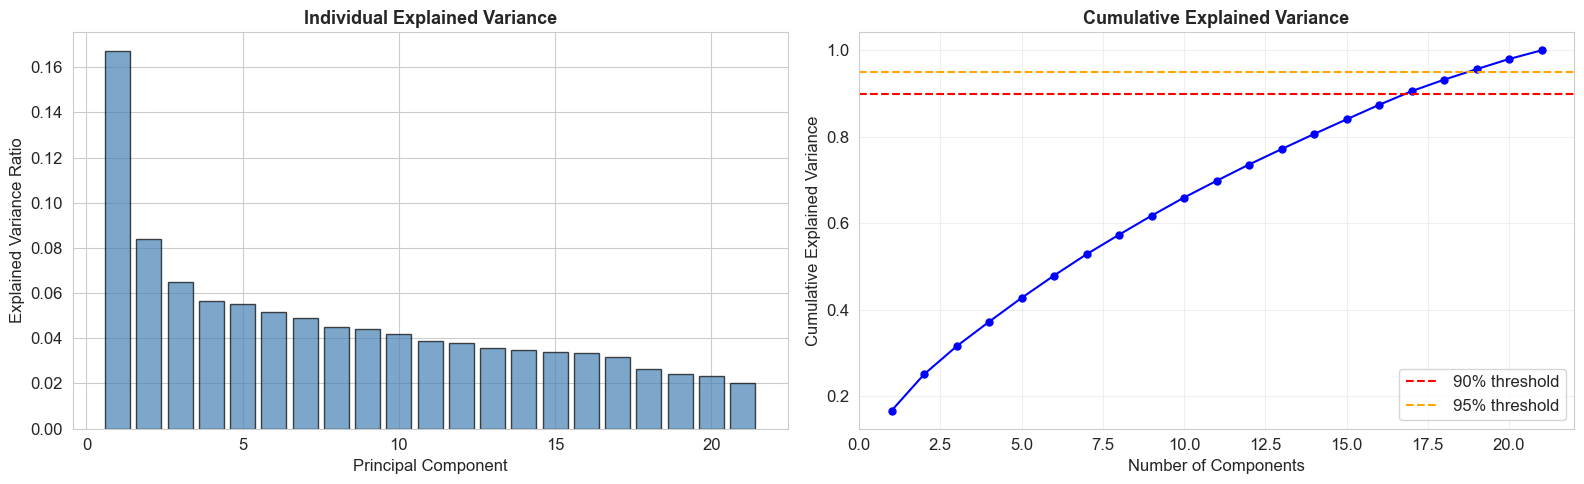

In [20]:
# Full PCA to see explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Individual explained variance
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
           pca_full.explained_variance_ratio_, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual Explained Variance', fontsize=13, fontweight='bold')

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, 'bo-', markersize=5)
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Find number of components for 90% and 95% variance
n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f'Components for 90% variance: {n_90}')
print(f'Components for 95% variance: {n_95}')

plt.tight_layout()
plt.savefig('../notebooks/figures/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Statistical Tests - Chi-Square Test for Binary Features

Using Chi-Square tests to verify the statistical significance of the relationship between binary features and diabetes status.

In [21]:
# Chi-Square test for binary features vs target
print('=== Chi-Square Test: Binary Features vs Diabetes Status ===')
print(f'{"Feature":25s} {"Chi2":>12s} {"p-value":>15s} {"Cramers V":>12s} {"Significant":>12s}')
print('-' * 80)

chi2_results = []
for col in binary_features:
    contingency = pd.crosstab(df[col], df['Diabetes_012'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    # Cramer's V for effect size
    n = contingency.sum().sum()
    min_dim = min(contingency.shape[0], contingency.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    significant = 'Yes' if p_value < 0.05 else 'No'
    chi2_results.append({'Feature': col, 'Chi2': chi2, 'p_value': p_value, 'Cramers_V': cramers_v})
    print(f'{col:25s} {chi2:12.1f} {p_value:15.2e} {cramers_v:12.4f} {significant:>12s}')

# ANOVA for continuous features vs target
print('\n=== ANOVA Test: Continuous Features vs Diabetes Status ===')
print(f'{"Feature":25s} {"F-statistic":>12s} {"p-value":>15s} {"Significant":>12s}')
print('-' * 65)

for col in continuous_features:
    groups = [df[df['Diabetes_012'] == cls][col] for cls in [0, 1, 2]]
    f_stat, p_value = stats.f_oneway(*groups)
    significant = 'Yes' if p_value < 0.05 else 'No'
    print(f'{col:25s} {f_stat:12.1f} {p_value:15.2e} {significant:>12s}')

=== Chi-Square Test: Binary Features vs Diabetes Status ===
Feature                           Chi2         p-value    Cramers V  Significant
--------------------------------------------------------------------------------
HighBP                         18794.6        0.00e+00       0.2722          Yes
HighChol                       11258.9        0.00e+00       0.2107          Yes
CholCheck                       1173.7       1.33e-255       0.0680          Yes
Smoker                          1010.5       3.72e-220       0.0631          Yes
Stroke                          2916.8        0.00e+00       0.1072          Yes
HeartDiseaseorAttack            8244.9        0.00e+00       0.1803          Yes
PhysActivity                    3789.3        0.00e+00       0.1222          Yes
Fruits                           454.3        2.19e-99       0.0423          Yes
Veggies                          893.8       8.03e-195       0.0594          Yes
HvyAlcoholConsump                850.3       2.26

## 12. Key EDA Findings Summary

### Data Quality:
1. **No missing values** - The dataset is clean with 253,680 rows and 22 columns, all non-null.
2. **Duplicate rows**: ~9.4% (23,899) duplicate rows exist. Since this is survey data where different individuals can give identical responses, we retain them.
3. **All features are float64** - Binary/ordinal features are encoded numerically.

### Class Imbalance:
4. **Severe class imbalance** - No Diabetes: 84.2%, Prediabetes: 1.8%, Diabetes: 13.9%.
5. Prediabetes class is extremely rare — for classification, we will **binarise the target** (0 = No Diabetes, 1 = Diabetes/Prediabetes) and apply **SMOTE or class weighting**.

### Feature Insights:
6. **Strongest predictors** (by correlation): GenHlth (+0.30), HighBP (+0.27), BMI (+0.22), DiffWalk (+0.22), HighChol (+0.21).
7. **Mutual information** confirms non-linear importance: GenHlth, Age, BMI, HighBP rank highest.
8. **Negative associations**: Income (-0.17), Education (-0.13), PhysActivity (-0.12) — higher socioeconomic status and activity reduce diabetes risk.
9. **Statistical tests**: All binary features show statistically significant association with diabetes (p < 0.05). ANOVA confirms continuous features differ significantly across diabetes groups.

### Outliers:
10. **BMI**: 3.88% outliers (values > 41.5), right-skewed with a long tail.
11. **MentHlth/PhysHlth**: Highly zero-inflated distributions — most people report 0 days of poor health, but >14% flagged as "outliers" by IQR method. These are not true outliers but reflect the nature of health survey data.

### PCA Observations:
12. 2 PCA components capture limited variance — the classes **overlap significantly** in 2D space, indicating that classification will be challenging and will require multiple features.
13. Around 14-16 components needed for 90-95% variance — moderate dimensionality reduction possible.

### Implications for Modelling:
- **Classification**: Must handle class imbalance (SMOTE, class weights). Binarise target. Use tree-based models that handle mixed feature types well.
- **Clustering**: StandardScaler needed before clustering. PCA overlap suggests clusters may not align perfectly with diabetes labels — useful for discovering latent health profiles.
- **Feature engineering**: Consider interaction features (e.g., HighBP × HighChol) or grouped risk scores.